In [2]:
# Cell 1: Setup and imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
import time
import copy
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
transform_train_vgg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

transform_test_vgg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

train_ds = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train_vgg)
test_ds  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test_vgg)

train_loader_vgg = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader_vgg  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Train size:", len(train_ds), "Test size:", len(test_ds))


Train size: 50000 Test size: 10000


In [4]:
weights = models.VGG16_Weights.DEFAULT
model_vgg = models.vgg16(weights=weights)

# Freeze feature extractor for feature extraction
for p in model_vgg.features.parameters():
    p.requires_grad = False

# Replace top classification layer for CIFAR-10 (10 classes)
model_vgg.classifier[6] = nn.Linear(4096, 10)

model_vgg = model_vgg.to(device)

criterion_vgg = nn.CrossEntropyLoss()

optimizer_vgg = optim.SGD(
    filter(lambda p: p.requires_grad, model_vgg.parameters()),
    lr=0.01,
    momentum=0.9
)

In [5]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total


In [7]:
import pandas as pd


num_epochs = 5
history_vgg = []

for epoch in range(num_epochs):
    model_vgg.train()
    running_loss = 0.0
    running_corrects = 0
    running_total = 0


    for x, y in train_loader_vgg:
        x, y = x.to(device), y.to(device)

        optimizer_vgg.zero_grad()

        loss = criterion_vgg(model_vgg(x), y)
        loss.backward()
        optimizer_vgg.step()
        running_loss += loss.item() * x.size(0)
        _, preds = torch.max(model_vgg(x), 1)






    train_acc = accuracy(model_vgg, train_loader_vgg)
    val_acc   = accuracy(model_vgg, test_loader_vgg)

    history_vgg.append((epoch+1, train_acc, val_acc))

    print(f"Epoch {epoch+1} | Loss={running_loss/len(train_loader_vgg):.4f} | "
          f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

df_vgg = pd.DataFrame(history_vgg, columns=["Epoch", "Training Accuracy", "Validation Accuracy"])
df_vgg


Epoch 1 | Loss=13.3808 | Train Acc=0.9147 | Val Acc=0.8526
Epoch 2 | Loss=9.5514 | Train Acc=0.9589 | Val Acc=0.8759
Epoch 3 | Loss=7.1404 | Train Acc=0.9750 | Val Acc=0.8820
Epoch 4 | Loss=5.8973 | Train Acc=0.9830 | Val Acc=0.8837
Epoch 5 | Loss=4.8113 | Train Acc=0.9825 | Val Acc=0.8796


,Epoch,Training Accuracy,Validation Accuracy
0,1,0.91466,0.8526
1,2,0.95888,0.8759
2,3,0.97500,0.8820
3,4,0.98304,0.8837
4,5,0.98252,0.8796


In [20]:
import pandas as pd

# Count parameters
frozen_params = sum(p.numel() for p in model_vgg.features.parameters())
trainable_params = sum(p.numel() for p in model_vgg.parameters() if p.requires_grad)

# Create summary table
layer_table = pd.DataFrame({
    "Category": ["Frozen Layers",
                 "Trainable Layers"],

    "Number of Parameters": [frozen_params, trainable_params]
})

layer_table


,Category,Number of Parameters
0,Frozen Layers,14714688
1,Trainable Layers,119586826


In [21]:
import matplotlib.pyplot as plt

def save_table_as_image(df, filename, title):
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.axis('off')
    ax.set_title(title)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close(fig)

In [22]:
save_table_as_image(layer_table, "Part_D_Frozen_Trainable_Table.png",
                    "Part D: Frozen vs Trainable Layers")

In [11]:
save_table_as_image(df_vgg, "PartD_VGG_Accuracy.png",
                    "Part D: VGG16 Transfer Learning Accuracy")

In [12]:
import pandas as pd

df_c = pd.read_csv("df_c.csv")


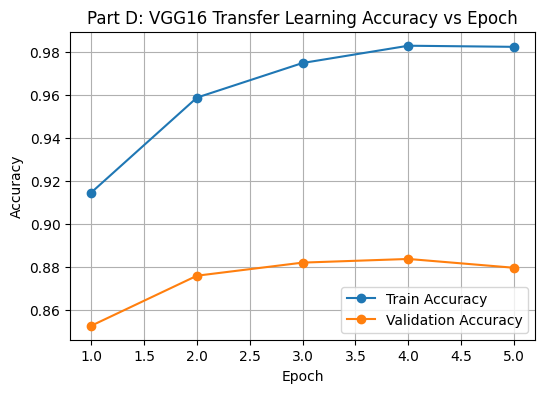

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(df_vgg["Epoch"], df_vgg["Training Accuracy"], marker='o', label="Train Accuracy")
plt.plot(df_vgg["Epoch"], df_vgg["Validation Accuracy"], marker='o', label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part D: VGG16 Transfer Learning Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


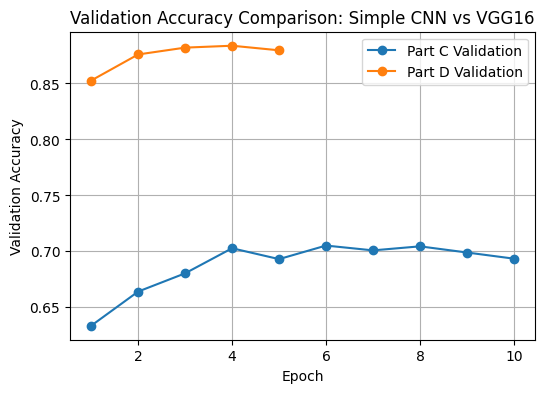

In [14]:
import matplotlib.pyplot as plt
df_c_5 = df_c[df_c["Epoch"] <= 5]
plt.figure(figsize=(6,4))

plt.plot(df_c["Epoch"], df_c["Validation Accuracy"],
         marker='o', label="Part C Validation")

plt.plot(df_vgg["Epoch"], df_vgg["Validation Accuracy"],
         marker='o', label="Part D Validation")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison: Simple CNN vs VGG16")
plt.legend()
plt.grid(True)
plt.show()
